In [1]:
import os
import glob

import pandas as pd

import fiftyone as fo

from tator_tools.download_media import MediaDownloader
from tator_tools.fiftyone_clustering import FiftyOneDatasetViewer
from tator_tools.download_query import QueryDownloader
from tator_tools.yolo_dataset import YOLODataset
from tator_tools.yolo_crop_regions import YOLORegionCropper
from tator_tools.train_model import ModelTrainer
from tator_tools.inference_video import VideoInferencer

from yolo_tiler import YoloTiler, TileConfig

# Download Query from Tator

In [ ]:
# Set parameters
api_token = os.getenv("TATOR_TOKEN")
project_id = 70  # 155

# Search string comes from Tator's Data Metadata Export utility
search_string = "eyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJtZXRob2QiOiJPUiIsIm9wZXJhdGlvbnMiOlt7ImF0dHJpYnV0ZSI6IkNvbW1vbk5hbWUiLCJvcGVyYXRpb24iOiJpY29udGFpbnMiLCJpbnZlcnNlIjp0cnVlLCJ2YWx1ZSI6ImNjYSJ9LHsiYXR0cmlidXRlIjoiQ29tbW9uTmFtZSIsIm9wZXJhdGlvbiI6Imljb250YWlucyIsImludmVyc2UiOnRydWUsInZhbHVlIjoiY3VwIn0seyJhdHRyaWJ1dGUiOiJDb21tb25OYW1lIiwib3BlcmF0aW9uIjoiaWNvbnRhaW5zIiwiaW52ZXJzZSI6dHJ1ZSwidmFsdWUiOiJlbmNydXN0aW5nIn1dfSx7Im1ldGhvZCI6IkFORCIsIm9wZXJhdGlvbnMiOlt7ImF0dHJpYnV0ZSI6IkluZGl2aWR1YWxDb3VudCIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoiMSJ9LHsiYXR0cmlidXRlIjoiJGNyZWF0ZWRfYnkiLCJvcGVyYXRpb24iOiJlcSIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6MzUyfV19LHsibWV0aG9kIjoiT1IiLCJvcGVyYXRpb25zIjpbeyJhdHRyaWJ1dGUiOiIkdHlwZSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjo1NTd9LHsiYXR0cmlidXRlIjoiJHR5cGUiLCJvcGVyYXRpb24iOiJlcSIsImludmVyc2UiOmZhbHNlLCJ2YWx1ZSI6NTAwfSx7ImF0dHJpYnV0ZSI6IiR0eXBlIiwib3BlcmF0aW9uIjoiZXEiLCJpbnZlcnNlIjpmYWxzZSwidmFsdWUiOjI1OH0seyJhdHRyaWJ1dGUiOiIkdHlwZSIsIm9wZXJhdGlvbiI6ImVxIiwiaW52ZXJzZSI6ZmFsc2UsInZhbHVlIjoyNDd9XX1dfQ=="

# Demo for downloading labeled data
frac = 1.0

dataset_name = "MDBC_MR"
output_dir = "E:/JordanP/Click-a-Coral/data/reduced"

label_field = ["ScientificName", "CommonName", "PercentCover", "IndividualCount"]

In [63]:
# Create a downloader for the labeled data
downloader = QueryDownloader(api_token,
                             project_id=project_id,
                             search_string=search_string,
                             frac=frac,
                             output_dir=output_dir,
                             dataset_name=dataset_name,
                             label_field=label_field,
                             download_width=1920)

NOTE: Authentication successful for jordan.pierce
NOTE: Search string saved to E:\JordanP\Click-a-Coral\data\reduced\MDBC\search_string.txt


In [64]:
# Download the labeled data
downloader.download_data()

NOTE: Querying Tator for labeled data
NOTE: Found 23668 objects in query


Processing query: 100%|██████████| 23668/23668 [00:02<00:00, 9663.66it/s]


NOTE: Found 23668 query objects after sampling
NOTE: Data saved to E:\JordanP\Click-a-Coral\data\reduced\MDBC\data.csv
NOTE: Data saved to E:\JordanP\Click-a-Coral\data\reduced\MDBC\data.json
NOTE: Downloading images to E:\JordanP\Click-a-Coral\data\reduced\MDBC\images


Retrying download for media 12328674, frame 0 again...


NOTE: Images downloaded to E:\JordanP\Click-a-Coral\data\reduced\MDBC\images


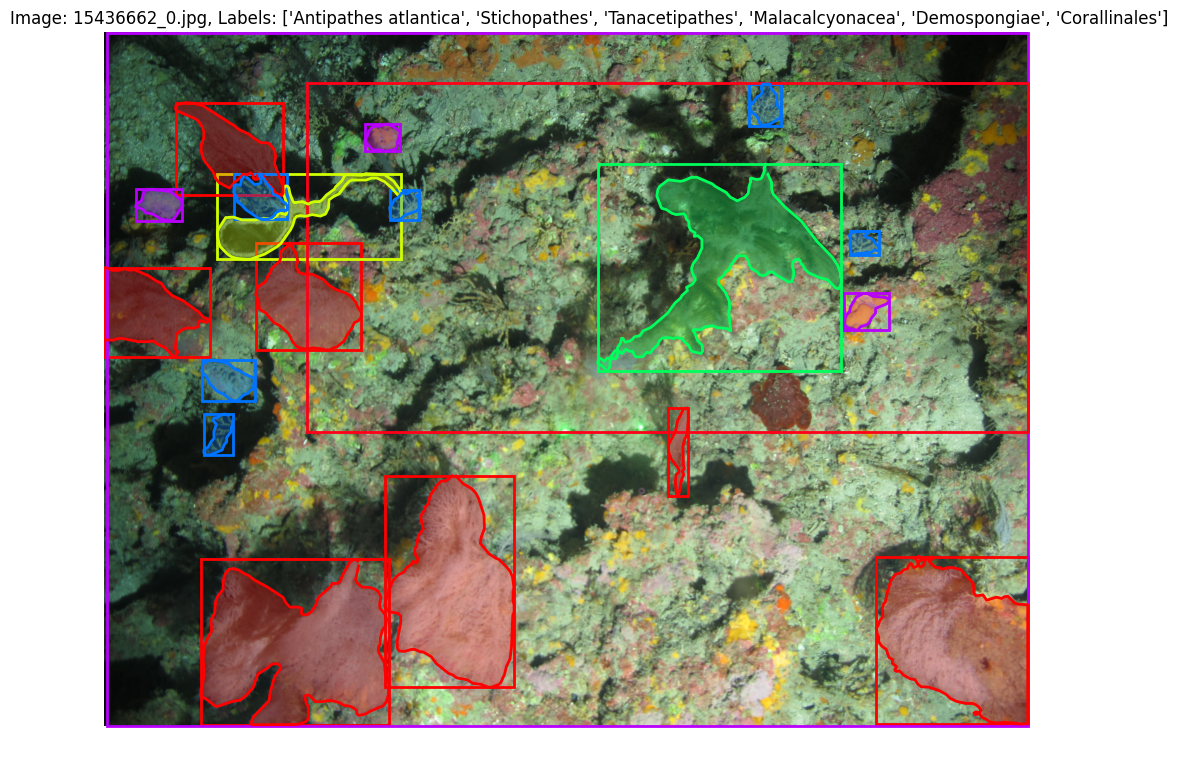

In [65]:
downloader.display_sample(label_column="ScientificName")

In [66]:
df = downloader.as_dataframe()  # .as_dict()

# Drop all rows with media that contain teleostei in their scientific name
media_w_baitfish = df[df['ScientificName'].str.contains("teleostei", case=False)]['media'].unique().tolist()
df = df[~df['media'].isin(media_w_baitfish)]

# Drop any rows without bounding boxes
df = df.dropna(subset=["x", "y", "width", "height"])
# Drop any rows with cup in their common name
df = df[~df['CommonName'].str.contains("cup", case=False)]
# Dropw any rows with crustose in their common name
df = df[~df['CommonName'].str.contains("crustose", case=False)]
# Drop any rows with corallinales in their common name
df = df[~df['ScientificName'].str.contains("corallinales", case=False)]
# Drop any rows with encrusting in their common name
df = df[~df['CommonName'].str.contains("encrusting", case=False)]
# Drop any rows with an individual count != 1
df = df[df['IndividualCount'] == 1]

# Fill all NAN PercentCover with 100
df['PercentCover'] = df['PercentCover'].fillna(100)
# Drop any rows with PercentCover < 100
df = df[df['PercentCover'] == 100]


# Update the label field to be the ScientificName
df['label'] = df['ScientificName']

print(df.shape, df.columns)

df.sample(10) 

(16050, 16) Index(['media', 'frame', 'image_name', 'image_path', 'image_width',
       'image_height', 'x', 'y', 'width', 'height', 'polygon',
       'ScientificName', 'CommonName', 'PercentCover', 'IndividualCount',
       'label'],
      dtype='object')


,media,frame,image_name,image_path,image_width,image_height,x,y,width,height,polygon,ScientificName,CommonName,PercentCover,IndividualCount,label
15439,15437071,0,15437071_0.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC\ima...,None,None,0.472588,0.331506,0.472039,0.632675,"[[0.5268640350877193, 0.35635964912280704], [0...",Leiopathes glaberrima,black coral,100.0,1.0,Leiopathes glaberrima
9700,13440941,0,13440941_0.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC\ima...,None,None,0.556921,0.479886,0.034568,0.026445,"[[0.566554878100191, 0.4859309270950669], [0.5...",Demospongiae,unknown sponge,100.0,1.0,Demospongiae
13277,15433074,0,15433074_0.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC\ima...,None,None,0.486294,0.655336,0.037281,0.044956,"[[0.5233004385964912, 0.6560672514619883], [0....",Antipatharia,,100.0,1.0,Antipatharia
9625,13440856,0,13440856_0.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC\ima...,None,None,0.226425,0.000000,0.429550,0.361111,"[[0.22642543859649122, 0.0], [0.22697368421052...",Stichopathes sp.,,100.0,1.0,Stichopathes sp.
13382,15433152,0,15433152_0.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC\ima...,None,None,0.430688,0.891035,0.061635,0.077919,"[[0.4347967128027682, 0.9038190439574523], [0....",Comatulida,,100.0,1.0,Comatulida
13339,15433126,0,15433126_0.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC\ima...,None,None,0.928981,0.553644,0.049879,0.098216,"[[0.9332748095368177, 0.5703802069854339], [0....",Malacalcyonacea,gorgonian coral,100.0,1.0,Malacalcyonacea
16442,15434991,0,15434991_0.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC\ima...,None,None,0.140434,0.288699,0.089055,0.277339,"[[0.21022213037457352, 0.2886987044472443], [0...",Thesea nivea,purple Thesea,100.0,1.0,Thesea nivea
6163,12328731,0,12328731_0.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC\ima...,None,None,0.479715,0.737573,0.032346,0.030702,"[[0.4830043859649123, 0.7394005847953217], [0....",Anthomastinae,,100.0,1.0,Anthomastinae
16801,15435257,0,15435257_0.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC\ima...,None,None,0.515820,0.506835,0.166980,0.128018,"[[0.5188022534293668, 0.5127987983341575], [0....",Thesea nivea,purple Thesea,100.0,1.0,Thesea nivea
4371,12328114,0,12328114_0.jpg,E:\JordanP\Click-a-Coral\data\reduced\MDBC\ima...,None,None,0.073808,0.122858,0.046385,0.048664,"[[0.09421347912635251, 0.12678485740363407], [...",Scleracis guadalupensis,,100.0,1.0,Scleracis guadalupensis


# Convert Data into YOLO-formatted Dataset

In [67]:
# Set parameters
output_dir = "E:/JordanP/Click-a-Coral/data/reduced/MDBC"
dataset_name = "YOLO_Detection_Dataset"

train_ratio = 0.8
test_ratio = 0.1

task = 'detect' # 'detect' or 'segment'

In [68]:
# Create and process dataset
dataset = YOLODataset(
    data=df,
    output_dir=output_dir,
    dataset_name=dataset_name,
    train_ratio=train_ratio,
    test_ratio=test_ratio,
    task=task,
    format_class_names=True, 
)

In [69]:
# Process the dataset
dataset.process_dataset(move_images=False)  # Makes a copy of the images instead of moving them

Processing YOLO dataset with 16050 annotations...
Dataset split: 1572 train, 198 valid, 196 test images


Writing detection labels:   0%|          | 0/1966 [00:00<?, ?it/s]

Copying images:   0%|          | 0/1966 [00:00<?, ?it/s]

Dataset created at E:\JordanP\Click-a-Coral\data\reduced\MDBC\YOLO_Detection_Dataset
Classes: ['Acanthuridae', 'Actiniaria', 'Aiolochroiacrassa', 'Anguilliformes', 'Anomura', 'Antennariidae', 'Anthiadidae', 'Anthiadinae', 'Anthiidae', 'Anthiinae', 'Anthomastinae', 'Anthozoa', 'Antipatharia', 'Antipathesatlantica', 'Antipathesfurcata', 'Apogonidae', 'Apogonpseudomaculatus', 'Arthropoda', 'Asterinidae', 'Asteroidea', 'Auletta', 'Aulettasp.', 'Bathynecteslongispina', 'Bebryce', 'Bebrycesp.', 'Bivalvia', 'Bodianuspulchellus', 'Bothidae', 'Brachyura', 'Bryozoa', 'Bubarida', 'Calliostomabenedicti', 'Caridea', 'Ceriantharia', 'Chaetodonocellatus', 'Chaetodonsedentarius', 'Chaetodontidae', 'Chironephthya', 'Chlorophyta', 'Chromisenchrysura', 'Cidaridae', 'Comatulida', 'Coronasterbriareus', 'Crinoidea', 'Crustacea', 'Decapoda', 'Decapodiformes', 'Demospongiae', 'Desmophyllumpertusum', 'Diadematidae', 'Dictyonellidae', 'Diodogorgia', 'Echinoidea', 'Elatopathesabietina', 'Ellisella', 'Ellisellida

Rendering Examples:   0%|          | 0/10 [00:00<?, ?it/s]

Rendered 10 examples to E:\JordanP\Click-a-Coral\data\reduced\MDBC\YOLO_Detection_Dataset\examples


In [ ]:
dataset.dataset_dir

# Tile Dataset (Optional)

In [ ]:
src = dataset.dataset_dir               # Source YOLO dataset directory
dst = f"{dataset.dataset_dir}_Tiled"    # Output directory for tiled dataset

config = TileConfig(
    # Size of each tile (width, height). Can be:
    # - Single integer for square tiles: slice_wh=640
    # - Tuple for rectangular tiles: slice_wh=(640, 480)
    slice_wh=(1920, 1080),

    # Overlap between adjacent tiles. Can be:
    # - Single float (0-1) for uniform overlap percentage: overlap_wh=0.1
    # - Tuple of floats for different overlap in each dimension: overlap_wh=(0.1, 0.1)
    # - Single integer for pixel overlap: overlap_wh=64
    # - Tuple of integers for different pixel overlaps: overlap_wh=(64, 48)
    overlap_wh=(0.2, 0.2),

    # Input image file extension to process
    input_ext=".jpg",

    # Output image file extension to save (default: same as input_ext)
    output_ext=None,

    # Type of YOLO annotations to process:
    # - "object_detection": Standard YOLO format (class, x, y, width, height)
    # - "instance_segmentation": YOLO segmentation format (class, x1, y1, x2, y2, ...)
    annotation_type="object_detection",

    # Include negative samples (tiles without any instances)
    include_negative_samples=True
)

tiler = YoloTiler(
    source=src,
    target=dst,
    config=config,
    num_viz_samples=15,                     # Number of samples to visualize
    show_processing_status=True,            # Show the progress of the tiling process
)

In [ ]:
tiler.run() 

In [75]:
dataset.dataset_dir

'E:\\JordanP\\Click-a-Coral\\data\\reduced\\MDBC\\YOLO_Detection_Dataset'

# Crop Regions (Optional)

In [76]:
cropper = YOLORegionCropper(dataset_path=f"{dataset.dataset_dir}\\data.yaml", 
                            output_dir=f"{os.path.dirname(dataset.dataset_dir)}",
                            dataset_name="YOLO_Classification_Dataset",
                            format_class_names=False)

In [77]:
# Process the dataset to create classification crops
cropper.process_dataset()

NOTE: Loading dataset...
NOTE: Converting dataset...
Added 1572 images from train dataset
Added 198 images from validation dataset
Added 196 images from test dataset


SupervisionWarnings: Passing a `Dict[str, np.ndarray]` into `DetectionDataset` is deprecated and will be removed in `supervision-0.26.0`. Use a list of paths `List[str]` instead.


NOTE: Loaded dataset - 16050 detections found


Creating crops: 100%|██████████| 1966/1966 [01:00<00:00, 32.34it/s] 


Created 16050 crops from 1966 images
NOTE: Writing classification dataset YAML...
Classification dataset YAML written to E:\JordanP\Click-a-Coral\data\reduced\MDBC/YOLO_Classification_Dataset/data.yaml
Class distribution:
  Acanthuridae: train=0, val=1, test=0
  Actiniaria: train=128, val=48, test=25
  Aiolochroiacrassa: train=16, val=9, test=3
  Anguilliformes: train=2, val=0, test=0
  Anomura: train=8, val=2, test=1
  Antennariidae: train=1, val=0, test=0
  Anthiadidae: train=26, val=9, test=5
  Anthiadinae: train=1, val=2, test=0
  Anthiidae: train=4, val=0, test=0
  Anthiinae: train=27, val=8, test=7
  Anthomastinae: train=21, val=4, test=4
  Anthozoa: train=1, val=0, test=0
  Antipatharia: train=480, val=117, test=63
  Antipathesatlantica: train=369, val=113, test=60
  Antipathesfurcata: train=502, val=163, test=78
  Apogonidae: train=12, val=3, test=1
  Apogonpseudomaculatus: train=0, val=2, test=0
  Arthropoda: train=1, val=0, test=0
  Asterinidae: train=0, val=0, test=1
  Aster

# Cluster Using FiftyOne

In [96]:
import torch
from ultralytics import YOLO

import numpy as np

from tqdm import tqdm

# ----------------------------------------------------------------------------------------------------------------------
# Functions
# ----------------------------------------------------------------------------------------------------------------------


def calculate_embeddings(df: pd.DataFrame, model_weights: str, imgsz: int, image_column: str = "Path") -> np.ndarray:
    """
    Calculate embeddings for a given dataframe using a YOLO model.
    """
    # Load the model
    model = YOLO(model_weights)
    # Get the image size
    imgsz = model.__dict__['overrides']['imgsz']

    # Get the device
    device ='cuda' if torch.cuda.is_available() else 'cpu'
    print(f"NOTE: Using device {device}")

    # Run a blank image through the model to load the weights
    _ = model(np.zeros((imgsz, imgsz, 3), dtype=np.uint8), device=device) 

    embeddings_list = []

    # Use the length of df as the total for tqdm
    total_items = len(df)
    for path in tqdm(df['Path'].tolist(), total=total_items, desc="Calculating embeddings"):
        embeddings = model.embed(path, imgsz=imgsz, stream=False, device=device, verbose=False)
        embeddings_list.append(embeddings[0].cpu().numpy())
    
    # Convert the embeddings list to a numpy array
    embeddings = np.array(embeddings_list)
     
    # Clear the cache
    torch.cuda.empty_cache()  
    
    return embeddings

In [97]:
dataset_path = "E:/JordanP/Click-a-Coral/data/reduced/MDBC/YOLO_Classification_Dataset"

In [114]:
import glob

train_images = glob.glob(f"{dataset_path}\\train\\**\\*.jpg", recursive=True)
valid_images = glob.glob(f"{dataset_path}\\valid\\**\\*.jpg", recursive=True)
test_images = glob.glob(f"{dataset_path}\\test\\**\\*.jpg", recursive=True)

images = train_images + valid_images + test_images
labels = [os.path.basename(os.path.dirname(image)) for image in images]

mapping = {label: i for i, label in enumerate(set(labels))}
label_id = [mapping[label] for label in labels]

images[0], labels[0], label_id[0]


('E:/JordanP/Click-a-Coral/data/reduced/MDBC/YOLO_Classification_Dataset\\train\\Actiniaria\\Actiniaria_0_12327951_0.jpg',
 'Actiniaria',
 90)

In [101]:
embeddings = calculate_embeddings(labeled_df,
                                  model_weights=f"{dataset_path}/results/yolov8n/weights/best.pt",
                                  imgsz=256,
                                  image_column="Path")

NOTE: Using device cuda

0: 256x256 Decapodiformes 0.01, Anthomastinae 0.01, Madrepora 0.01, Madreporasp 0.01, Zoantharia 0.01, 6.6ms
Speed: 2.6ms preprocess, 6.6ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)


Calculating embeddings: 100%|██████████| 12776/12776 [01:56<00:00, 109.88it/s]


In [150]:
labeled_df = pd.DataFrame({
    "Path": images,
    "Label": labels,
    "Label_ID": label_id,
}).astype("string[python]")

In [151]:
labeled_df['Label']

0        Actiniaria
1        Actiniaria
2        Actiniaria
3        Actiniaria
4        Actiniaria
            ...    
12771    Zoantharia
12772    Zoantharia
12773    Zoantharia
12774    Zoantharia
12775    Zoantharia
Name: Label, Length: 12776, dtype: string

In [152]:
# Initialize the viewer with the path to the directory containing images
viewer = FiftyOneDatasetViewer(dataframe=labeled_df,
                               image_path_column='Path',
                               feature_columns=['Label', 'Label_ID'],
                               nickname='MDBC_Image',
                               custom_embeddings=embeddings,        # Pass the embeddings, or None
                               clustering_method='umap',      # umap, pca, tsne
                               num_dims=2)                    # Number of dimensions for UMAP (2 or 3)

In [153]:
# Process the dataset to create the FiftyOne dataset and generate the UMAP visualization
viewer.process_dataset()

Overwriting existing dataset: MDBC_Image


TypeError: Cannot interpret 'string[python]' as a data type

In [154]:
# Launch the FiftyOne app
try:
    session = fo.launch_app(viewer.dataset)
except:
    # Weird behavior in notebook
    session = fo.launch_app(viewer.dataset)

# Train a YOLO Model

In [ ]:
dir_ = "E:\\tator-tools\\Data\\Labeled_Data\\MR_Downward_Facing_Imagery\\YOLODataset_Detection"

# Initialize the trainer with the required parameters
trainer = ModelTrainer(
    training_data=f"{dir_}\\data.yaml",
    weights="yolov8m.pt",
    output_dir=f"{dir_}\\Training",
    name="yolov8m",
    task='detect',
    epochs=50,
    half=True,
    imgsz=640,
    single_cls=False,
    plots=True,
    batch=0.5,
)

In [ ]:
# Train the model
trainer.train_model()

In [ ]:
# Evaluate on the model (if test data is available)
trainer.evaluate_model()

# Inference on Video

In [ ]:
# Set parameters
model_weights = "E:\\tator-tools\\Data\\Labeled_Data\\AUV_Polygons\\YOLODataset_Detection_Tiled\\Training\\AUV_Polygons_Detection\\weights\\best.pt"

video_path = "E:\\tator-tools\\Data\\Raw_Videos\\GL2301_VID_20230725T145731Z_D015_DROPCAM_HIGH_converted.mp4"
output_dir = "E:\\tator-tools\\Data\\Inference_Results"


In [ ]:
inferencer = VideoInferencer(
    weights_path=model_weights,
    model_type='yolo',
    video_path=video_path,
    output_dir=output_dir,
    start_at=1000,
    end_at=2000,
    conf=0.5,
    iou=0.3,
    track=False,
    segment=False,
    sahi=False,
    show=True
)

In [ ]:
inferencer.inference()